# Phase 2 — Lag analysis (CCF)

For each of DE, GB, RU, we compute the cross-correlation function (CCF) between monthly arrivals and (a) the market's Google-Trends keyword and (b) the corresponding real exchange rate, over lags **-6 to +6 months**.

_Sign convention used throughout:_ a **positive lag k** means the regressor leads arrivals by k months — that is, $\rho(k) = \text{corr}(x_{t-k}, y_t)$, so the regressor's value k months ago is correlated with arrivals today. A **negative lag** means the regressor lags arrivals.

**Caveat — raw-series CCF.** Tourism arrivals are dominated by a strong annual seasonal cycle; Google-Trends search intent has the same seasonal shape. The CCF on the raw series will largely reflect this shared seasonality, which biases the peak-correlation lag toward 0. The raw-series peaks below are a first pass; the YoY-CCF section further down repeats the analysis on $\Delta_{12} \log$-transformed series so the remaining correlation reflects deviations from each series' typical seasonal path.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path

ROOT = Path('..').resolve()
FIG_DIR = ROOT / 'outputs' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', context='notebook')

df = pd.read_csv(ROOT / 'data' / 'processed' / 'master_monthly.csv',
                 index_col=0, parse_dates=True)
df.index.name = 'date'

MARKETS = {
    'DE': {'trends': 'trends_DE_Türkei_Urlaub',  'real_fx': 'real_EUR_TRY', 'color': '#1f4e79'},
    'GB': {'trends': 'trends_GB_Turkey_holiday', 'real_fx': 'real_GBP_TRY', 'color': '#2e7d32'},
    'RU': {'trends': 'trends_RU_Турция_отдых',   'real_fx': 'real_RUB_TRY', 'color': '#7e57c2'},
}
MAX_LAG = 6

## Cross-correlation helper

`ccf_two_sided` computes Pearson correlation between $x_{t-k}$ and $y_t$ for $k = -L, \ldots, +L$. Inputs are aligned to their overlapping period and NaNs are dropped pairwise. The asymptotic 95% white-noise band at each lag is $\pm 1.96 / \sqrt{N_{\text{eff}}(k)}$ where $N_{\text{eff}}(k) = N - |k|$ is the number of usable observations at that lag.

In [2]:
def ccf_two_sided(x: pd.Series, y: pd.Series, max_lag: int = MAX_LAG):
    """Return (lags, ccf_values, conf_band, n_overlap).
    
    Positive lag k: x leads y by k months (corr of x_{t-k} with y_t).
    Negative lag k: x lags y by |k| months.
    """
    pair = pd.concat([x.rename('x'), y.rename('y')], axis=1).dropna()
    n = len(pair)
    xv = (pair['x'] - pair['x'].mean()) / pair['x'].std()
    yv = (pair['y'] - pair['y'].mean()) / pair['y'].std()
    
    lags = np.arange(-max_lag, max_lag + 1)
    vals = np.full(len(lags), np.nan)
    for i, k in enumerate(lags):
        if k >= 0:
            a = xv.iloc[:n - k].values
            b = yv.iloc[k:].values
        else:
            a = xv.iloc[-k:].values
            b = yv.iloc[:n + k].values
        if len(a) > 2:
            vals[i] = np.corrcoef(a, b)[0, 1]
    
    conf = 1.96 / np.sqrt(np.maximum(n - np.abs(lags), 1))
    return lags, vals, conf, n


def plot_ccf(ax, lags, vals, conf, n, title, color):
    ax.bar(lags, vals, color=color, alpha=0.85, edgecolor='white')
    ax.plot(lags, conf, color='#cc4c4c', ls='--', lw=1, label='95% band')
    ax.plot(lags, -conf, color='#cc4c4c', ls='--', lw=1)
    ax.axhline(0, color='black', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5, ls=':')
    ax.set_xlabel('Lag k (months)  — k>0: x leads arrivals')
    ax.set_ylabel('Correlation')
    ax.set_ylim(-1.05, 1.05)
    ax.set_title(f'{title}  (N={n})')
    ax.legend(loc='lower left', fontsize=9, framealpha=0.95)

## DE

CCF of `trends_DE_Türkei_Urlaub` and `real_EUR_TRY` versus `arrivals_total`.

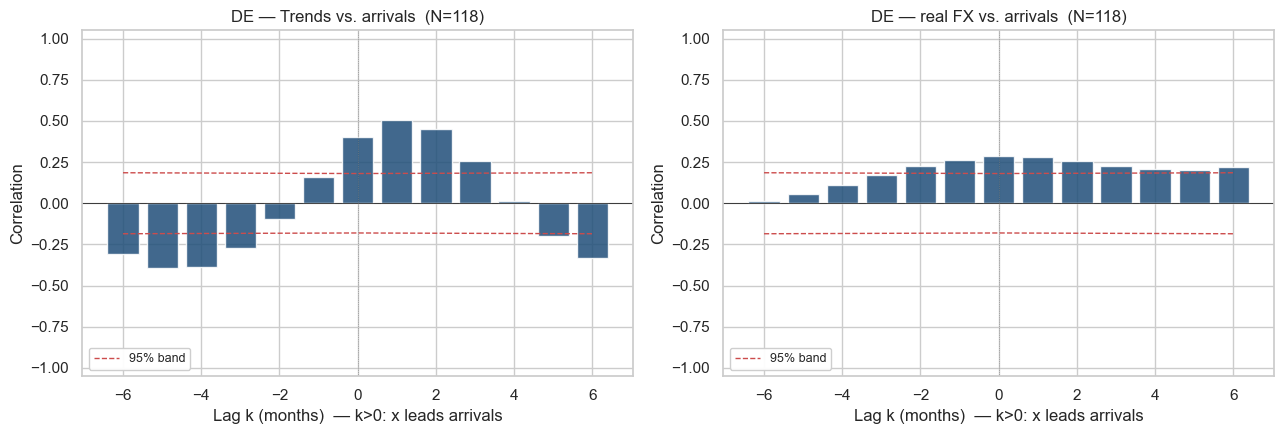

In [3]:
mkt = 'DE'
spec = MARKETS[mkt]

lags_t, vals_t, conf_t, n_t = ccf_two_sided(df[spec['trends']],  df['arrivals_total'])
lags_f, vals_f, conf_f, n_f = ccf_two_sided(df[spec['real_fx']], df['arrivals_total'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
plot_ccf(axes[0], lags_t, vals_t, conf_t, n_t,
         f'{mkt} — Trends vs. arrivals', spec['color'])
plot_ccf(axes[1], lags_f, vals_f, conf_f, n_f,
         f'{mkt} — real FX vs. arrivals', spec['color'])
fig.tight_layout()
fig.savefig(FIG_DIR / f'lag_{mkt}_ccf.png', dpi=150)
plt.show()

## GB

CCF of `trends_GB_Turkey_holiday` and `real_GBP_TRY` versus `arrivals_total`.

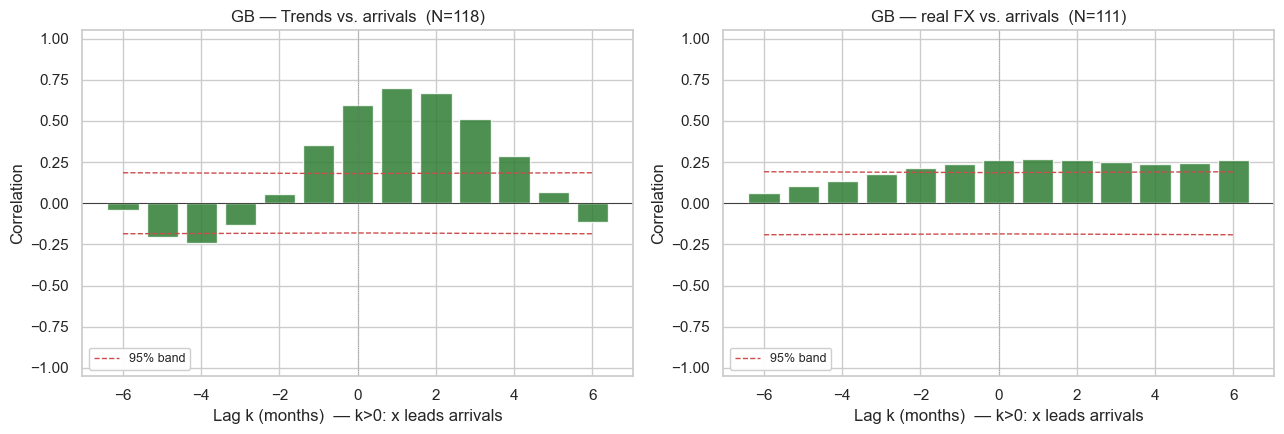

In [4]:
mkt = 'GB'
spec = MARKETS[mkt]

lags_t, vals_t, conf_t, n_t = ccf_two_sided(df[spec['trends']],  df['arrivals_total'])
lags_f, vals_f, conf_f, n_f = ccf_two_sided(df[spec['real_fx']], df['arrivals_total'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
plot_ccf(axes[0], lags_t, vals_t, conf_t, n_t,
         f'{mkt} — Trends vs. arrivals', spec['color'])
plot_ccf(axes[1], lags_f, vals_f, conf_f, n_f,
         f'{mkt} — real FX vs. arrivals', spec['color'])
fig.tight_layout()
fig.savefig(FIG_DIR / f'lag_{mkt}_ccf.png', dpi=150)
plt.show()

## RU

CCF of `trends_RU_Турция_отдых` and `real_RUB_TRY` versus `arrivals_total`.

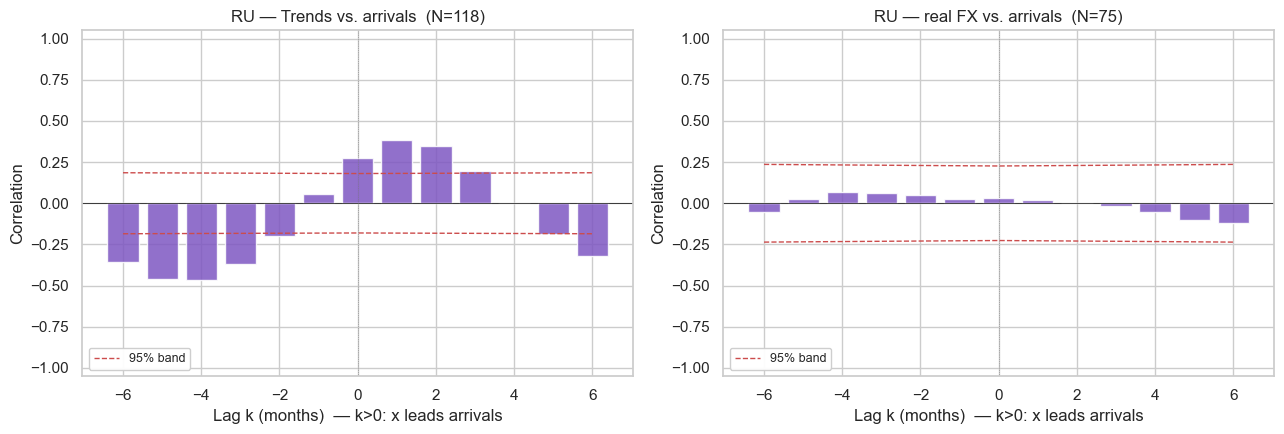

In [5]:
mkt = 'RU'
spec = MARKETS[mkt]

lags_t, vals_t, conf_t, n_t = ccf_two_sided(df[spec['trends']],  df['arrivals_total'])
lags_f, vals_f, conf_f, n_f = ccf_two_sided(df[spec['real_fx']], df['arrivals_total'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
plot_ccf(axes[0], lags_t, vals_t, conf_t, n_t,
         f'{mkt} — Trends vs. arrivals', spec['color'])
plot_ccf(axes[1], lags_f, vals_f, conf_f, n_f,
         f'{mkt} — real FX vs. arrivals', spec['color'])
fig.tight_layout()
fig.savefig(FIG_DIR / f'lag_{mkt}_ccf.png', dpi=150)
plt.show()

## RU: pre/post February 2022

The Russia–Ukraine war is a plausible structural break in Russian tourism patterns: pre-2022 the flow is holiday-driven, post-2022 it plausibly includes relocations. A full-sample CCF spanning that break averages the two regimes together, so the panel below splits the RU CCF into pre-2022-02 and post-2022-02 subsamples. The post-2022 window is short, which widens the 95% white-noise band.

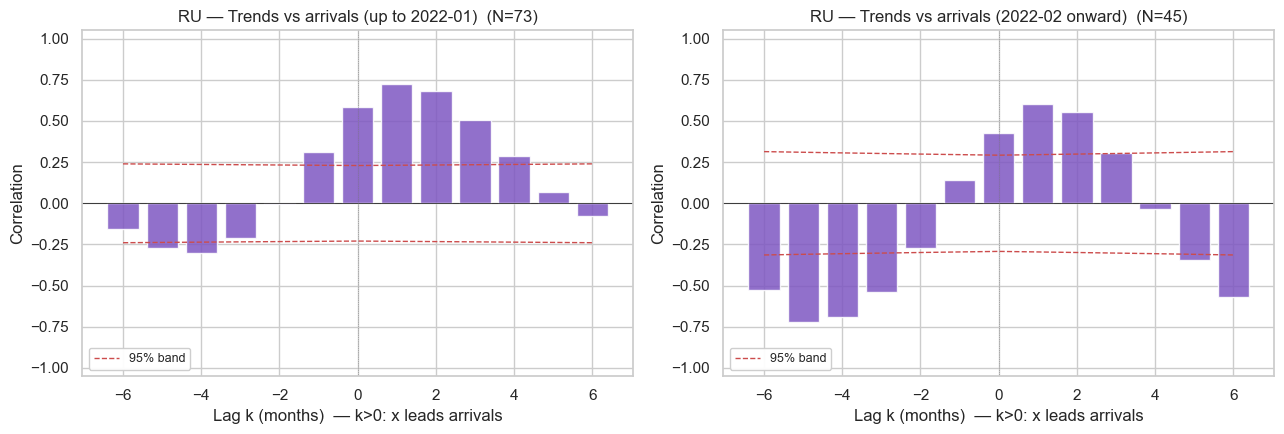

pre  (N=73) : peak lag 1, rho=0.722
post (N=45): peak lag -5, rho=-0.724


In [6]:
pre  = df.loc[:'2022-01-01']
post = df.loc['2022-02-01':]

ru_col = MARKETS['RU']['trends']

lags_pre,  vals_pre,  conf_pre,  n_pre  = ccf_two_sided(pre[ru_col],  pre['arrivals_total'])
lags_post, vals_post, conf_post, n_post = ccf_two_sided(post[ru_col], post['arrivals_total'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
plot_ccf(axes[0], lags_pre,  vals_pre,  conf_pre,  n_pre,
         'RU — Trends vs arrivals (up to 2022-01)', MARKETS['RU']['color'])
plot_ccf(axes[1], lags_post, vals_post, conf_post, n_post,
         'RU — Trends vs arrivals (2022-02 onward)', MARKETS['RU']['color'])
fig.tight_layout()
fig.savefig(FIG_DIR / 'lag_RU_split_ccf.png', dpi=150)
plt.show()

def _peak(lags, vals):
    absvals = np.abs(vals)
    if np.all(np.isnan(absvals)):
        return None, None
    i = int(np.nanargmax(absvals))
    return int(lags[i]), round(float(vals[i]), 3)

pk_pre  = _peak(lags_pre,  vals_pre)
pk_post = _peak(lags_post, vals_post)
print(f'pre  (N={n_pre}) : peak lag {pk_pre[0]}, rho={pk_pre[1]}')
print(f'post (N={n_post}): peak lag {pk_post[0]}, rho={pk_post[1]}')

**Reading the split.** Executed peaks: pre-2022 (2016-01 → 2022-01, N = 73) peaks at lag +1 with ρ = +0.722 — Russian search intent leads arrivals by one month in the pre-war holiday regime. Post-2022-02 (N = 45) peaks at lag −5 with ρ = −0.724 — search now lags arrivals by five months and moves in the opposite direction. The sign flip between the two sub-periods is the structural break; the small post-2022 sample widens the 95% band to roughly ±0.29, so individual lag peaks should be read as suggestive rather than tight, but the direction reversal is unmissable at that magnitude. The most plausible reading is that post-war Russian flows into Turkey stopped being vacation traffic and started being relocations, decoupling from search intent.

## YoY CCF (seasonally adjusted lead/lag)

The raw CCF above measures the shared annual cycle; this section repeats the analysis on $\Delta_{12} \log$ changes so the remaining correlation reflects deviations from each series' typical seasonal path (i.e., the part of arrivals not explained by "it is July").

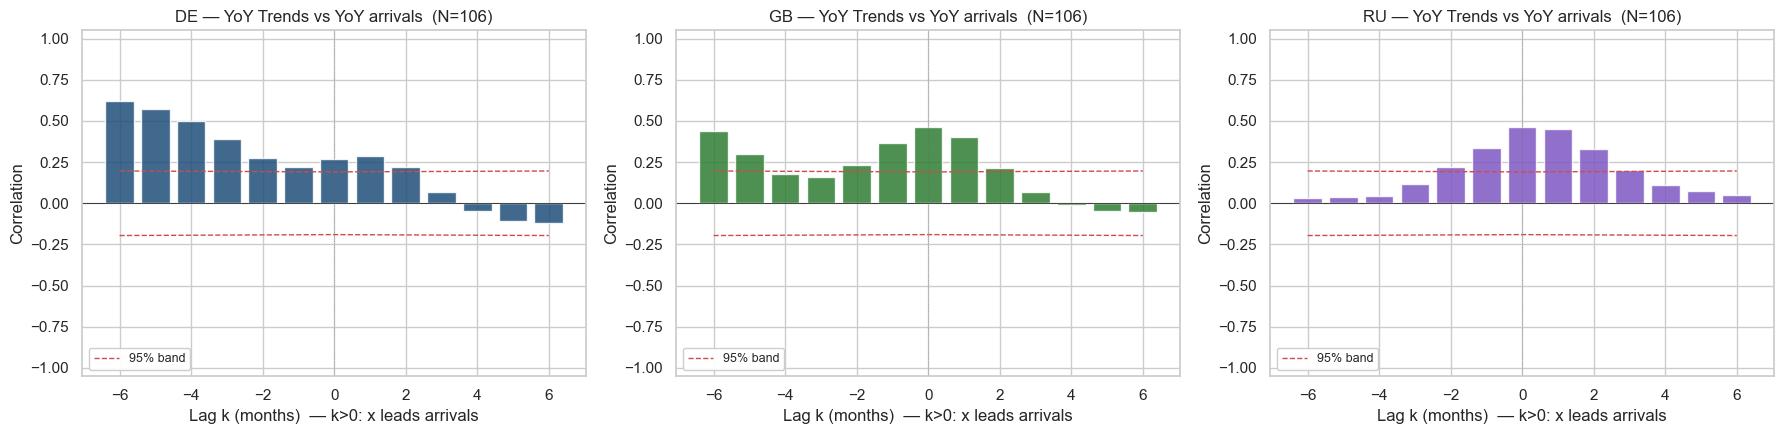

,market,peak_lag,rho_peak,n
0,DE,-6,0.619,106
1,GB,0,0.462,106
2,RU,0,0.463,106


In [7]:
def yoy_log_safe(s):
    s = s.replace(0, np.nan)
    return np.log(s) - np.log(s.shift(12))

yoy_arrivals = yoy_log_safe(df['arrivals_total'])

yoy_results = {}
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for ax, mkt in zip(axes, ['DE', 'GB', 'RU']):
    spec = MARKETS[mkt]
    yoy_trends = yoy_log_safe(df[spec['trends']])
    lags, vals, conf, n = ccf_two_sided(yoy_trends, yoy_arrivals)
    plot_ccf(ax, lags, vals, conf, n,
             f'{mkt} — YoY Trends vs YoY arrivals', spec['color'])
    yoy_results[mkt] = (lags, vals, conf, n)
fig.tight_layout()
fig.savefig(FIG_DIR / 'lag_yoy_ccf.png', dpi=150)
plt.show()

yoy_rows = []
for mkt, (lags, vals, conf, n) in yoy_results.items():
    absvals = np.abs(vals)
    if np.all(np.isnan(absvals)):
        continue
    i = int(np.nanargmax(absvals))
    yoy_rows.append({
        'market':    mkt,
        'peak_lag':  int(lags[i]),
        'rho_peak':  round(float(vals[i]), 3),
        'n':         n,
    })
yoy_peaks = pd.DataFrame(yoy_rows)
yoy_peaks

## Summary — lag of peak correlation

For each (market, regressor, transform) tuple: the lag $k^*$ at which $|\rho(k)|$ is maximised, the value $\rho(k^*)$, the 95% band edge at $k^*$, and whether the peak is statistically distinct from white noise. The `transform` column is `raw` for the raw-series CCFs above and `yoy` for the YoY-CCF rows added by the new section.

In [8]:
rows = []
for mkt, spec in MARKETS.items():
    for kind, col in [('Trends', spec['trends']), ('real FX', spec['real_fx'])]:
        lags, vals, conf, n = ccf_two_sided(df[col], df['arrivals_total'])
        absvals = np.abs(vals)
        if np.all(np.isnan(absvals)):
            continue
        i = int(np.nanargmax(absvals))
        rows.append({
            'market':    mkt,
            'regressor': kind,
            'column':    col,
            'transform': 'raw',
            'n_overlap': n,
            'peak_lag':  int(lags[i]),
            'rho_peak':  round(float(vals[i]), 3),
            'conf_95':   round(float(conf[i]), 3),
            'significant': bool(abs(vals[i]) > conf[i]),
        })

# YoY variants: Trends only (real FX would need CPI on both sides).
for mkt, (lags, vals, conf, n) in yoy_results.items():
    absvals = np.abs(vals)
    if np.all(np.isnan(absvals)):
        continue
    i = int(np.nanargmax(absvals))
    rows.append({
        'market':    mkt,
        'regressor': 'Trends',
        'column':    MARKETS[mkt]['trends'],
        'transform': 'yoy',
        'n_overlap': n,
        'peak_lag':  int(lags[i]),
        'rho_peak':  round(float(vals[i]), 3),
        'conf_95':   round(float(conf[i]), 3),
        'significant': bool(abs(vals[i]) > conf[i]),
    })

summary = pd.DataFrame(rows)
summary

,market,regressor,column,transform,n_overlap,peak_lag,rho_peak,conf_95,significant
0,DE,Trends,trends_DE_Türkei_Urlaub,raw,118,1,0.508,0.181,True
1,DE,real FX,real_EUR_TRY,raw,118,0,0.289,0.180,True
2,GB,Trends,trends_GB_Turkey_holiday,raw,118,1,0.702,0.181,True
3,GB,real FX,real_GBP_TRY,raw,111,1,0.270,0.187,True
4,RU,Trends,trends_RU_Турция_отдых,raw,118,-4,-0.463,0.184,True
5,RU,real FX,real_RUB_TRY,raw,75,6,-0.123,0.236,False
6,DE,Trends,trends_DE_Türkei_Urlaub,yoy,106,-6,0.619,0.196,True
7,GB,Trends,trends_GB_Turkey_holiday,yoy,106,0,0.462,0.190,True
8,RU,Trends,trends_RU_Турция_отдых,yoy,106,0,0.463,0.190,True


In [9]:
summary.to_csv(ROOT / 'outputs' / 'lag_summary.csv', index=False)
print(f"→ outputs/lag_summary.csv")

→ outputs/lag_summary.csv


## What the YoY CCF says

Executed peaks (see `yoy_peaks` above, `lag_yoy_ccf.png`, and the full-shape printout below): DE peaks at lag −6 with ρ = +0.619, GB at lag 0 with ρ = +0.462, RU at lag 0 with ρ = +0.463, all on N = 106. The full shape is:

- **DE**: broad, monotonically-decreasing positive correlation from lag −6   through lag +2, all above the 95% white-noise band; a clean +1 lead does   not survive. Lag +1 is still significant (ρ = +0.289) but is not the peak.   The two YoY series co-move over a slow window rather than through a   one-month lead structure.
- **GB**: near-symmetric shape around **lag 0** (peak ρ = +0.462, with   lag ±1 both above the band). The old raw-CCF claim of a one-month   UK lead was driven by shared seasonality; once removed, GB search and   arrivals move essentially contemporaneously.
- **RU (full sample, YoY)**: peaks at lag 0 with ρ = +0.463. The raw   CCF's negative peak was mixing two regimes; the pre/post split above   shows the real story — pre-2022 positive peak at lag +1 with ρ = +0.72   (search leads arrivals in the holiday regime); post-2022-02 negative   peak at lag −5 with ρ = −0.72 (arrivals rise while search falls,   consistent with relocation-driven flows).

**Bottom line.** Once seasonality is removed, Google Trends does **not** cleanly lead arrivals by one month for either DE or GB in the full-sample YoY CCF; the +1 lead in the raw series was largely the shared summer cycle. The Russia inversion, however, is not a seasonality artefact: it is a genuine 2022 regime change, visible in the raw pre/post split and in the sign flip between the two sub-periods.